# Oh surface inversion tutorial


This notebook shows how to run the legacy Oh surface inversion on the UAVSAR multilooked GRD covariance product for `winnip_09002_12060_004_120714_L090_CX_02`, together with a matching incidence-angle raster.


## How the input product was prepared

The example data used here were prepared in three steps:

- Download the free UAVSAR multilooked GRD covariance product for `winnip_09002_12060_004_120714_L090_CX_02` from the [UAVSAR website](https://uavsar.jpl.nasa.gov/).
- Import the covariance product into ESA SNAP and export it to NetCDF-BEAM format.
- Download the matching incidence-angle file for the same scene and use the annotation file (`.ann`) to retrieve the original incidence-angle raster dimensions.

In the notebook below we read the NetCDF-BEAM covariance product with `open_netcdf_beam`, load the incidence-angle raster, downsample it to match the multilooked grid, and then pass both inputs to `oh_surface_inversion`. The function converts other supported polarimetric representations to C3 before applying the inversion.


## Import packages and set directories


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar

from polsarpro.io import open_netcdf_beam
from polsarpro.physical_inversion import oh_surface_inversion

# change these paths to match your local files
product_id = "winnip_09002_12060_004_120714_L090_CX_02"

input_uavsar_nc = Path(f"/data/psp/test_files/{product_id}_ML5X5.nc")
incidence_angle_file = Path(f"/data/psp/test_files/{product_id}.inc")
output_dir = Path("/data/psp/res")
output_dir.mkdir(parents=True, exist_ok=True)
file_out = output_dir / "oh_surface_inversion_winnip_python.nc"

# Thresholds use the same order as the Dubois API.
thresh1_db = -5.0  # maximum HV/VV ratio
thresh2_db = 0.0  # maximum HH/VV ratio


## Load the input product


In [2]:
C3 = open_netcdf_beam(input_uavsar_nc)


## Load and resample the incidence angle

We first open the incidence-angle raster at its original dimensions, then downsample it so it matches the 5x5 geocoded image used by the C3 product.


In [3]:
row_dim, col_dim = C3.dims

# use lines from .ann file (infer from auxiliary file)
# hgt.set_rows                         (pixels)        = 3767                   ; HGT Lines
# hgt.set_cols                         (pixels)        = 11636                  ; HGT Samples
nlines = 3767
ncols = 11636

# The incidence-angle file is a little-endian float32 stream in radians.
# Read only the raster-sized prefix and reshape it to the UAVSAR grid.
incidence_angle_values = np.fromfile(
    incidence_angle_file,
    dtype="<f4",
    count=nlines * ncols,
)

# Reduce to the same dimensions as multilooked 5x5 image.
incidence_angle_values[incidence_angle_values == -10000] = np.nan
incidence_angle = xr.DataArray(
    incidence_angle_values.reshape(nlines, ncols),
    dims=(row_dim, col_dim),
    name="incidence_angle",
).coarsen(y=5, x=5, boundary="trim").mean()


## Apply the inversion


In [4]:
with ProgressBar():
    oh_surface_inversion(
        C3,
        incidence_angle=incidence_angle,
        thresh1=thresh1_db,
        thresh2=thresh2_db,
    ).to_netcdf(file_out, mode="w")


[########################################] | 100% Completed | 5.06 sms


## Load the output file


In [5]:
res = xr.open_dataset(file_out)

The main Oh outputs are normalized surface roughness (`oh_ks`), relative dielectric constant (`oh_er`), volumetric moisture (`oh_mv`), and the combined validity mask (`oh_mask_valid_in_out`).


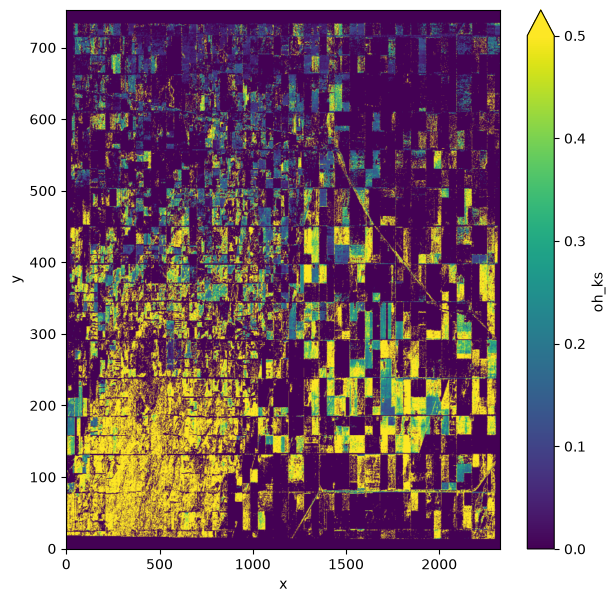

In [6]:
res.oh_ks.plot.imshow(
    cmap="viridis", vmax=0.5, interpolation="bilinear", figsize=(7, 7)
)


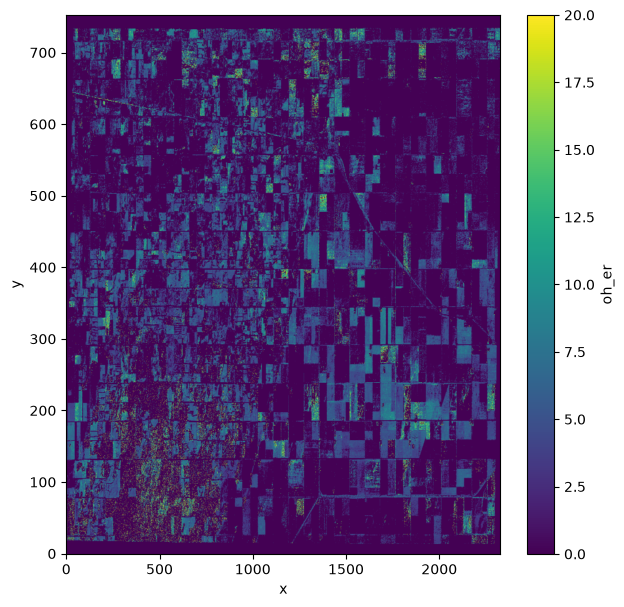

In [7]:
res.oh_er.plot.imshow(
    cmap="viridis", vmax=20, interpolation="bilinear", figsize=(7, 7)
)


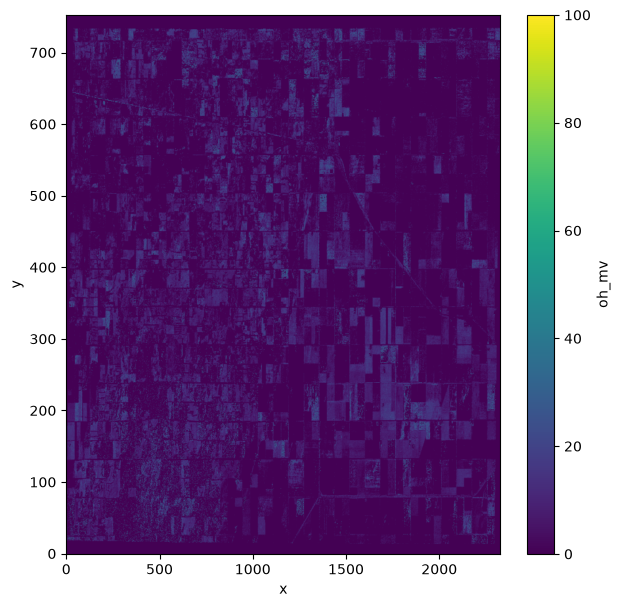

In [8]:
res.oh_mv.plot.imshow(
    cmap="viridis", vmax=100, interpolation="bilinear", figsize=(7, 7)
)


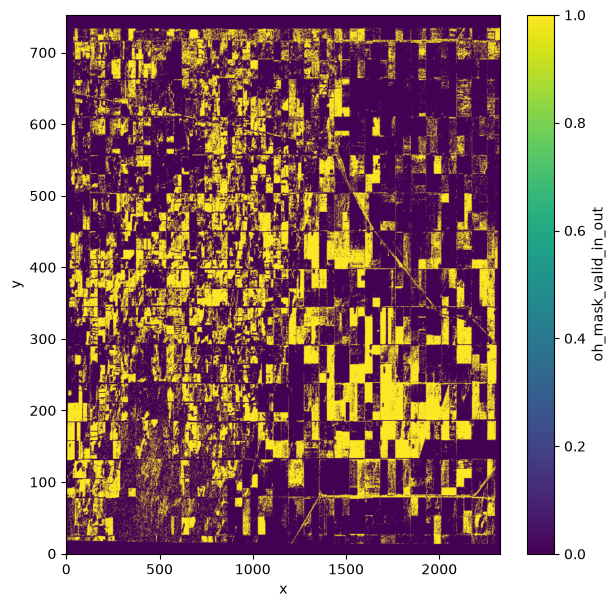

In [9]:
res.oh_mask_valid_in_out.plot.imshow(
    cmap="viridis", interpolation="bilinear", figsize=(7, 7)
)
